Partition:
Group 1: [1, 3, 5]
Group 2: [2, 12, 15]
Group 3: [4, 7, 9]
Group 4: [6, 17, 19]
Group 5: [8, 11, 13]
Group 6: [10, 18, 21]
Group 7: [14, 22, 23]
Group 8: [16, 20, 24]


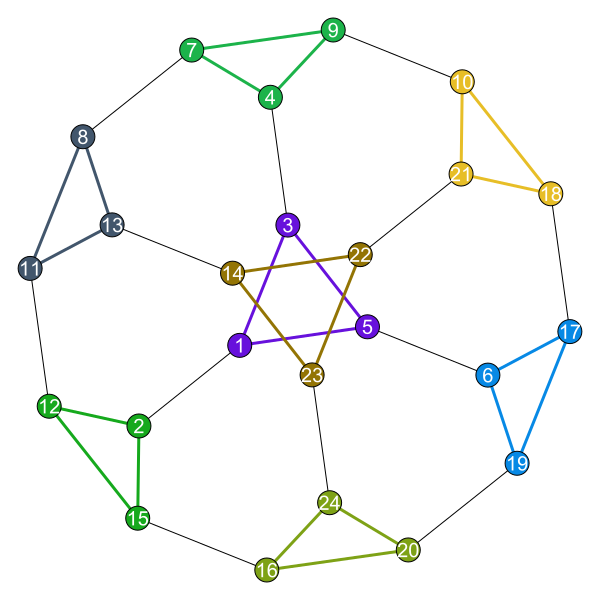

In [2]:
# -------------------------------------------------------------
#  Code for: "Introduction to Integer Programming and Applications with Julia"
#  Chapter: 5 – Graph problems
#  Section: 5.6 – Clique Partitioning Problem (CPP)
#  Author(s): Luiz Henrique Nogueira Lorena
# -------------------------------------------------------------

using JuMP                  # Modeling language
using HiGHS                 # Solver
using Graphs                # Graphs package
using Karnak                # Graphs Visualization package
using Colors                # Colors package
using Random                # Random number generation

# Function to plot the solution of the CPP
function plot_solution(graph, partition)
    # Vertex fill coloring based on partition
    n = Graphs.nv(graph)
    colors = [Colors.RGB(rand(), rand(), rand()) for _ in 1:maximum(partition)]
    vertexfillcolors = [colors[partition[i]] for i in 1:n]
    
    # Draw graph
    @drawsvg begin
        background("white")
        sethue("black")
        fontsize(20)
        drawgraph(
            graph,
            layout = stress,
            vertexshapesizes = 12,
            vertexlabels = 1:n,
            vertexfillcolors = vertexfillcolors,
            edgestrokecolors = (n, from, to, src, dst) -> begin
                # src and dst are vertex indices
                if partition[from] == partition[to]
                    colors[partition[from]]  # same color as partition
                else
                    colorant"black"  # inter-cluster edges
                end
            end,
            edgestrokeweights = (n, from, to, src, dst) -> begin
                # src and dst are vertex indices
                if partition[from] == partition[to]
                    3.0  # same weight as partition
                else
                    1.0 # inter-cluster edges
                end
            end
        )
    end
end

# Function to solve the Clique Partitioning Problem (CPP)
function solve_cpp(graph)
    # Get number of vertices and edges
    n = Graphs.nv(graph)
    m = Graphs.ne(graph)

    # Calculate constants
    const_2m = 1/(2 * m)
    const_4m2 = 1/(4 * m^2)

    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)

    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)

    # Define the decision variables
    @variable(model, x[i in 1:n-1, j in i+1:n], Bin)

    # Objective: maximize the weight of the selected edges
    objective = JuMP.AffExpr()
    for i in 1:n
        di = Graphs.degree(graph, i)
        objective -= (di * di * const_4m2)  # Constant C
        for j in i+1:n
            dj = Graphs.degree(graph, j)
            if Graphs.has_edge(graph, i, j)
                objective +=  (2 * (const_2m - (di * dj * const_4m2))) * x[i,j] 
            else
                objective +=  (2 * (- (di * dj * const_4m2))) * x[i,j] 
            end
        end
    end
    @objective(model, Max, objective)

    # Transitive Constraints: ensure that the selected edges form a valid partition
    for i in 1:n-2
        for j in i+1:n-1
            for k in j+1:n
                @constraint(model,  x[i,j] + x[j,k] - x[i,k] <= 1)
                @constraint(model,  x[i,j] - x[j,k] + x[i,k] <= 1)
                @constraint(model, -x[i,j] + x[j,k] + x[i,k] <= 1)
            end
        end
    end

    # Run the solver
    JuMP.optimize!(model)

    # Extract the optimal partition
    partition_id = 0
    partition = zeros(Int64, n)
    for i in 1:n - 1
        for j in i + 1:n
            if JuMP.value(x[i,j]) > 0.5
                if partition[i] == partition[j] == 0
                    partition[i] = partition_id
                    partition[j] = partition_id
                    partition_id += 1
                else
                    if partition[i] == 0
                        partition[i] = partition[j]
                    else
                        partition[j] = partition[i]
                    end
                end
            end
        end
    end

    # Ensure all clusters are labeled starting from 1
    if minimum(partition) == 0
        partition = partition .+ 1
    end

    # Group vertices by their partition
    groups = [[] for _ in 1:maximum(partition)]
    for u in 1:n
        group_id = partition[u]
        push!(groups[group_id], u)
    end

    # Print the partitioning
    println("Partition:")
    for (i, group) in enumerate(groups)
        println("Group $i: ", Int.(group))
    end

    # Plot solution
    plot_solution(graph, partition)
end

# Set random seed for reproducibility (group colors)
Random.seed!(0)

# Create graph
graph = Karnak.smallgraph("truncatedcube")

# Solve the Clique Partitioning Problem
solve_cpp(graph)